# More European Countries

This notebook shows the results of the analysis of Belgium, Italy, Portugal, Spain and Sweden

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from modules.RealRate import RealRate
from CompareCountries import COUNTRY_STYLES

"""
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["cmr10", "Computer Modern Roman"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,   # use ASCII hyphen instead of Unicode minus
    "figure.dpi": 300,
    "savefig.dpi": 300,
})
"""

'\nplt.rcParams.update({\n    "font.family": "serif",\n    "font.serif": ["cmr10", "Computer Modern Roman"],\n    "mathtext.fontset": "cm",\n    "axes.unicode_minus": False,   # use ASCII hyphen instead of Unicode minus\n    "figure.dpi": 300,\n    "savefig.dpi": 300,\n})\n'

In [2]:
START1 = 2000
END1 = 2012
START2 = 2014
END2 = 2024

COUNTRIES = {
    'Belgium': [(START1, END1), (START2, END2)],
    'Italy': [(START1, END1), (START2, END2)],
    'Portugal': [None, (START2, END2)], #no data for first period
    'Spain':[(START1, END1), (START2, END2)],
    'Sweden': [(START1, END1), (START2, END2)]

}

## Real Interest Rate

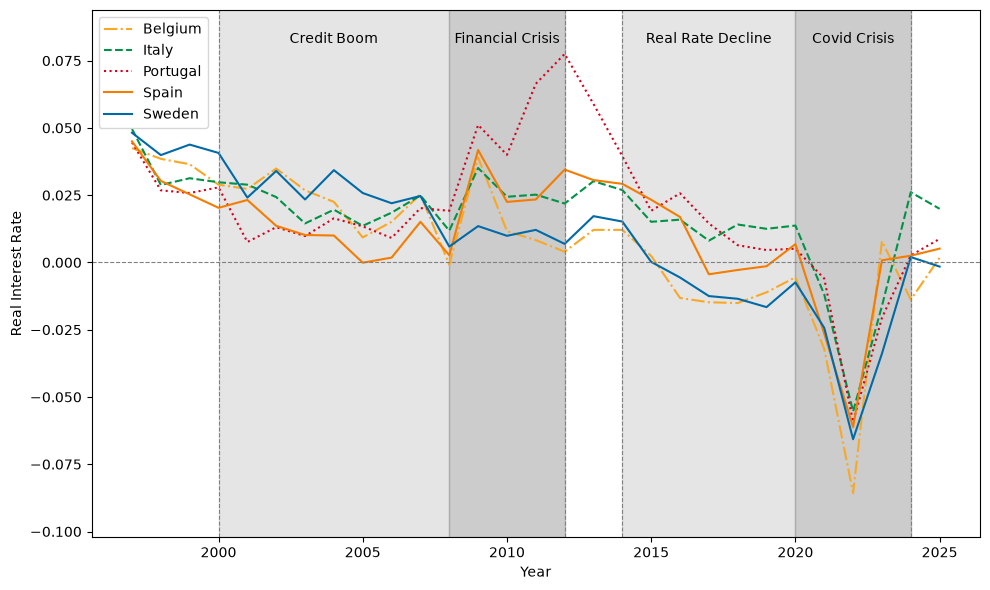

In [3]:


df = pd.DataFrame()
for country in COUNTRIES.keys():
    rr = RealRate(country)
    df = pd.concat([df, rr.df], axis=0, ignore_index=True)



fig, ax = plt.subplots(figsize=(10, 6))

for country, g in df.groupby('country'):
    color = COUNTRY_STYLES.get(country)['color']
    linestyle = COUNTRY_STYLES.get(country)['linestyle']
    ax.plot(g['year'], g['realinterestrate'], color=color, label=country, linestyle=linestyle)

ax.axvline(2000, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2012, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2014, color='grey', linewidth=0.8, linestyle='--')
ax.axvline(2024, color='grey', linewidth=0.8, linestyle='--')

ax.axvspan(2000, 2008, color='gray', alpha=0.2)
ax.text((2000 + 2008) / 2, ax.get_ylim()[1], 'Credit Boom', ha='center', va='top')

ax.axvspan(2008, 2012, color='gray', alpha=0.4)
ax.text((2008 + 2012) / 2, ax.get_ylim()[1], 'Financial Crisis', ha='center', va='top')

ax.axvspan(2014, 2020, color='gray', alpha=0.2)
ax.text((2014 + 2020) / 2, ax.get_ylim()[1], 'Real Rate Decline', ha='center', va='top')

ax.axvspan(2020, 2024, color='gray', alpha=0.4)
ax.text((2020 + 2024) / 2, ax.get_ylim()[1], 'Covid Crisis', ha='center', va='top')


ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Year')
ax.set_ylabel('Real Interest Rate')
ax.legend()
ax.margins(x=0.05, y=0.1)  
fig.tight_layout()
plt.show()


## Analysis

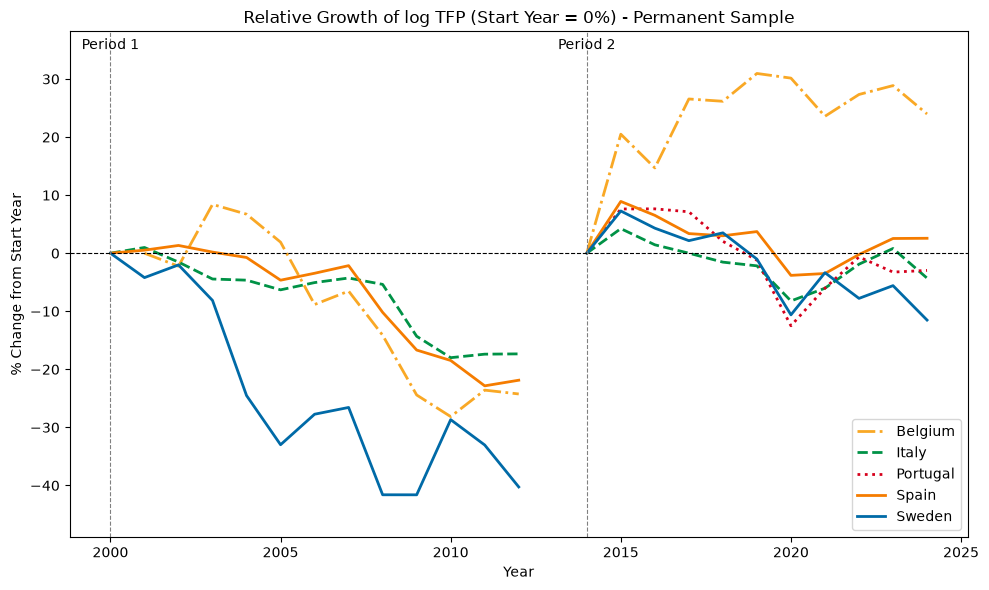

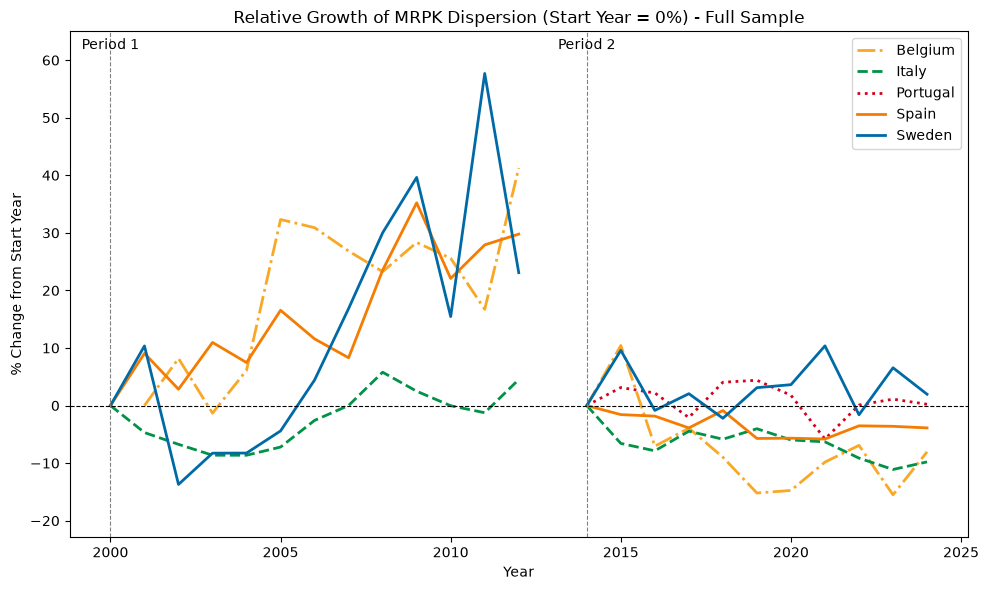

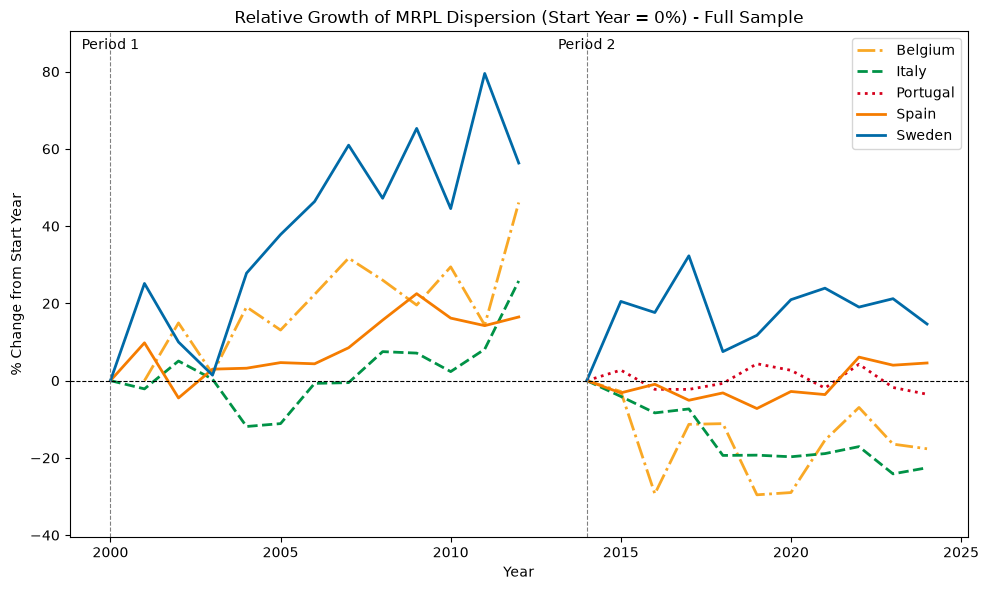

In [4]:
from CompareCountries import CompareCountries
from MisallocationAnalysis import MisallocationAnalysis

allanalises = []

for country, rangelist in COUNTRIES.items():
    for range in rangelist:
        if range == None:
            continue
        analysis = MisallocationAnalysis(country, range[0], range[1], sector='C')
        allanalises.append(analysis)

comparison = CompareCountries(allanalises)
tfpplot = comparison.plot_compare_sectoral_tfp('permanent')
mrpkplot = comparison.plot_compare_factor_products(figsize=(10,6),variable='MRPK',sample='full')
mrplplot = comparison.plot_compare_factor_products(figsize=(10,6),variable='MRPL',sample='full')

In [5]:
comparison.compare(sample='full')[['Country','Time', 'Revenue Data Coverage %']]

,Country,Time,Revenue Data Coverage %
0,Belgium,2000 - 2012,31.64
1,Belgium,2014 - 2024,32.91
2,Italy,2000 - 2012,25.85
3,Italy,2014 - 2024,42.00
4,Portugal,2014 - 2024,37.64
5,Spain,2000 - 2012,48.85
6,Spain,2014 - 2024,57.91
7,Sweden,2000 - 2012,9.92
8,Sweden,2014 - 2024,11.55


In [6]:
MOMENTS = ['Top 20% Share of k', 'Coef log_a on capital growth', 'Corr (log MRPK, log k)', 'Corr (log MRPK, log Z)']
comparison.compare_all_moments().loc[MOMENTS]

,Belgium 2000-2012,Belgium 2014-2024,Italy 2000-2012,Italy 2014-2024,Portugal 2014-2024,Spain 2000-2012,Spain 2014-2024,Sweden 2000-2012,Sweden 2014-2024
Top 20% Share of k,0.86,0.860,0.710,0.810,0.850,0.820,0.850,0.890,0.850
Coef log_a on capital growth,0.08,0.046,-1.279,0.017,0.051,0.038,0.048,0.082,0.018
"Corr (log MRPK, log k)",-0.28,-0.340,-0.220,-0.270,-0.260,-0.420,-0.380,-0.330,-0.300
"Corr (log MRPK, log Z)",0.38,0.320,0.360,0.250,0.330,0.170,0.290,0.150,0.190
